
Esta versión final del algoritmo implementa barreras de control para evitar colisiones.

Implementamos las bibliotecas pertinentes

In [2]:
%reset -f

import numpy as np
from numpy.linalg import pinv
import matplotlib.pyplot as plt
import random
from scipy.integrate import solve_ivp
from qpsolvers import solve_qp
from scipy.optimize import minimize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

Definimos los parámetros de la simulación, siendo $n = 2$ las dimensiones (no tocar), $nrob$ el número de robots, $t_{sim}$ el tiempo integrado, y $posmin$ y $posmax$ delimitan los límites en los que se disponen los robots de forma aleatoria. R es el radio de la región prohibida entorno a cada robot, P el proyector sobre las coordenadas reales y a el parámetro $\alpha$. 

In [3]:
n = 2
nrob = 10
t_sim = (0,100)
posmin = -2
posmax = 2

#Parámetros para configurar las barreras
R = 0.1
a = 1000
P = np.diag([1,1,0])

#Ganancias
kx = 2
ky = 2
kc = 1

A continuación definimos las funciones del algoritmo. $f(t)$ es la curva parametrizada a la que tienden los robots y $df(t)$ es la tangente a la curva. $phi(x,y,t)$ es la posición del robot respecto al punto de la curva $f(t)$.

In [4]:
def f(t):
    # fx = t*np.cos(t*2.4)/2
    # fy = t*np.sin(t)/1.5
    fx = np.cos(3*t)
    fy = np.sin(2*t)
    
    return np.array([fx, fy])

# Para los títulos de las gráficas
f_latex = r"\left[\cos(3\omega),\ \sin(2\omega)\right]"

def df(t,h=1e-5):
    Df = (f(t+h)-f(t-h))/(2*h)

    return np.array([Df[0], Df[1]])

def phi(x,y,t):
    phix = x - f(t)[0]
    phiy = y - f(t)[1]

    return np.array([phix,phiy])

Debemos resolver la ecuación diferencial numéricamente:  
  
$\quad\dot{\vec{x}} = \vec{v}(\vec{x})$  
  
Para ello, establecemos las condiciones iniciales, no permitiendo que ninguna condición inicial se de en una región prohibida.

In [ ]:
rob0 = []

for i in range(nrob):
    while True:
        x = random.uniform(posmin, posmax)
        y = random.uniform(posmin, posmax)

        #Comprobamos que ningun robot esté a una distancia inicialmente menor de 2R
        valido = True
        for j in range(i):
            xj = rob0[3*j]
            yj = rob0[3*j + 1]
            if np.sqrt((x - xj)**2 + (y - yj)**2) < 2*R:
                valido = False
                break

        if valido:
            break

    rob0.append(x)
    rob0.append(y)
    rob0.append(0)

rob0 = np.array(rob0)

Añadimos $c(\omega)$ a la última componente del campo, que se encarga de que los robots mantegan las distancias entre ellos. También, el vector $w^* = (w_1^*,\dots,w^*_N)$, que indica los w deseados para los robots, midiendo desde el primer robot hacia los de detrás. Además definimos la matriz D, que transforma las coordenadas $\omega^*$ en las distancias que deben mantener los robots entre ellos, $\Delta_{r,r'}$

In [6]:
wc = np.linspace(0, -np.pi, nrob)
print(wc)

D = np.zeros((nrob, nrob))
for i in range(nrob):
    D[i, i]          = -1
    D[i, (i-1)%nrob] =  1

delta = D.T @ wc
L     = D @ D.T

#Definimos la función c(w)
def c(w):
    return -L @ (w - wc)

[ 0.         -0.34906585 -0.6981317  -1.04719755 -1.3962634  -1.74532925
 -2.0943951  -2.44346095 -2.7925268  -3.14159265]


Ahora definimos la función $\vec{v}^{pf}(\vec{x})$, que define al campo vectorial que lleva a los robots a la trayectoria deseada

In [7]:
def vecpf(t,tray):
    evol = []

    for i in range(nrob):
        x = tray[3*i]
        y = tray[3*i+1]
        w = tray[3*i+2]
        evol.extend([df(w)[0]-kx*phi(x,y,w)[0],
             df(w)[1]-ky*phi(x,y,w)[1],
             1 + kx*phi(x,y,w)[0]*df(w)[0] + ky*phi(x,y,w)[1]*df(w)[1]])
        
    return np.array(evol)

Definimos la función $\vec{v}^{co}(\omega)$, que mantiene la distancia entre robots

In [8]:
def vecco(t,tray):
    w = []

    for i in range(nrob):
        w.append(tray[3*i+2])
    
    evol = []

    for i in range(nrob):
        evol.extend([0,0,c(w)[i]])

    return np.array(evol)

Definimos la función segura $\eta_{rr'}$. Ahora realizamos la optimización para comprobar cuando actúa la barrera de potencial de los robots vecinos. Para ello empleamos el optimizador solve_qp. Además, cambiamos la forma del array de posiciones para que sea más sencillo trabajar con los índices.

In [9]:
#Función segura
def seg(xi, xj):
    mod = P @ (xj.T - xi.T)
    return mod @ mod - R**2

#Dinámica  con optimizador integrado
def vec(t,tray):
    global t0
    while t - t0 >= umbral_impresion:
        t0 += umbral_impresion
        print(f"Integrando: t = {t0:.0f}")
    evol = vecpf(t,tray)+vecco(t,tray)

    x = tray.reshape(nrob,3)
    v = evol.reshape(nrob,3)

    for i in range (nrob):
        # Construimos las las restricciones de los vecinos de forma matricial
        A = []
        b = []

        #Recorremos cada restricción, que se corresponde con cada robot vecino r'
        for j in range (nrob-1):
            dist = x[(i+j+1)%nrob,:] - x[i,:]
            A.append(dist @ P)
            b.append(a * 0.25 * (seg(x[i,:], x[(i+j+1)%nrob,:]))**3)

        A = np.array(A)
        b = np.array(b)

        #Calculamos solución óptima con solver para el tipo de problemas como el nuestro
        wmod = solve_qp(np.eye(3), -v[i,:], A, b, solver="daqp")
        if wmod is None:
            wmod = v[i,:]

        #Si no resuelve, significa que w' = w, no se sobreescribe nada
        if wmod is not None:
            evol[3*i : 3*i+3] = wmod

    return evol

Resolvemos la ecuación. Se pueden cambiar las trayectorias más arriba en el código. Se añade un contador para saber cuánto lleva integrado. Si se baja, aparecen todos los plots pertinentes en relación con la trayectoria simulada. La animación de la trayectoria se encuentra abajo del todo

In [10]:
t0 = 0.0
umbral_impresion = 1.0

trayectoria = solve_ivp(vec, t_sim, rob0, method='RK45', rtol=1e-3, atol=1e-6, max_step=0.05)

Integrando: t = 1
Integrando: t = 2
Integrando: t = 3
Integrando: t = 4
Integrando: t = 5
Integrando: t = 6
Integrando: t = 7
Integrando: t = 8
Integrando: t = 9
Integrando: t = 10
Integrando: t = 11
Integrando: t = 12
Integrando: t = 13
Integrando: t = 14
Integrando: t = 15
Integrando: t = 16
Integrando: t = 17
Integrando: t = 18
Integrando: t = 19
Integrando: t = 20
Integrando: t = 21
Integrando: t = 22
Integrando: t = 23
Integrando: t = 24
Integrando: t = 25
Integrando: t = 26
Integrando: t = 27
Integrando: t = 28
Integrando: t = 29
Integrando: t = 30
Integrando: t = 31
Integrando: t = 32
Integrando: t = 33
Integrando: t = 34
Integrando: t = 35
Integrando: t = 36
Integrando: t = 37
Integrando: t = 38
Integrando: t = 39
Integrando: t = 40
Integrando: t = 41
Integrando: t = 42
Integrando: t = 43
Integrando: t = 44
Integrando: t = 45
Integrando: t = 46
Integrando: t = 47
Integrando: t = 48
Integrando: t = 49
Integrando: t = 50
Integrando: t = 51
Integrando: t = 52
Integrando: t = 53
In

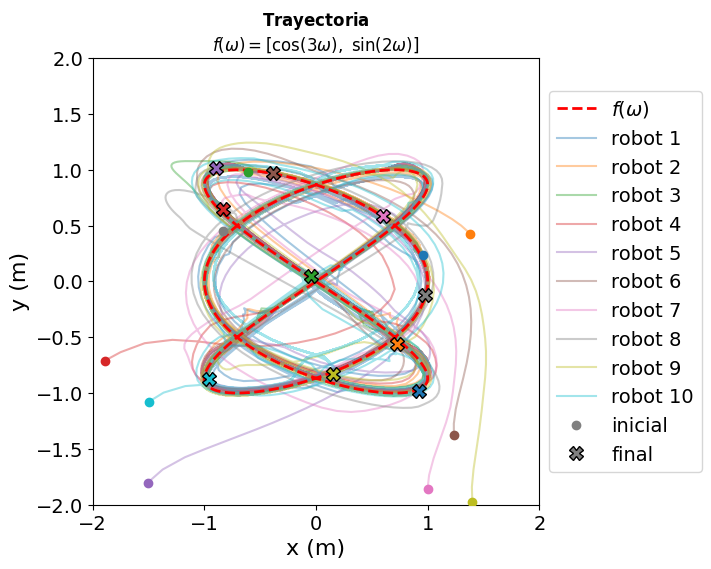

In [11]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)

w_curva = np.linspace(0, 2*np.pi, 1000)
ax.plot(f(w_curva)[0], f(w_curva)[1], 'r--', lw=2, label=r'$f(\omega)$', zorder=2.5)

for i in range(nrob):
    linea, = ax.plot(trayectoria.y[i*3], trayectoria.y[i*3+1], alpha=0.4, label=f'robot {i+1}', zorder=2)
    col = linea.get_color()
    ax.plot(trayectoria.y[i*3,0],  trayectoria.y[i*3+1,0],  marker='o', color=col, ls='', zorder=3)
    ax.plot(trayectoria.y[i*3,-1], trayectoria.y[i*3+1,-1], marker='X', color=col, mec='black', mew=1, ms=10, ls='', zorder=3)

ax.plot([], [], marker='o', color='gray', ls='', label='inicial')
ax.plot([], [], marker='X', color='gray', mec='black', mew=1, ms=10, ls='', label='final')

ax.set_aspect('equal')
ax.set_xlabel('x (m)', fontsize=16)
ax.set_ylabel('y (m)', fontsize=16)
ax.tick_params(labelsize=14)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=14)
ax.set_title(r"$\mathbf{Trayectoria}$" + "\n" + r"$f(\omega) = " + f_latex + r"$")
ax.set_xlim(posmin, posmax)
ax.set_ylim(posmin, posmax)
plt.show()

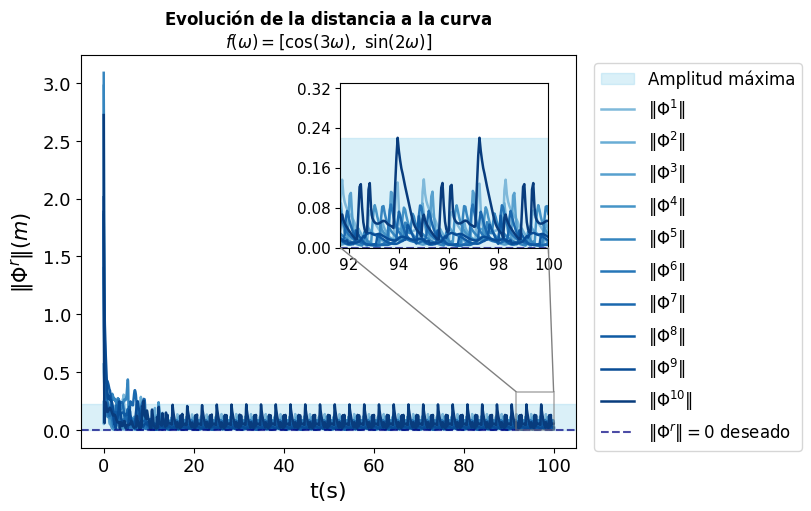

Amplitud máxima: 0.2201
Amplitud máxima normalizada: 0.0144


In [12]:
from matplotlib.patches import ConnectionPatch

zoom = True

#Cuánto zoom queremos hacer sobre el tiempo simulado
z = 12

Phi = []
for i in range(nrob):
    fr = f(trayectoria.y[3*i+2])
    dx = trayectoria.y[3*i]   - fr[0]
    dy = trayectoria.y[3*i+1] - fr[1]
    Phi.append(np.sqrt(dx**2 + dy**2))
Phi = np.array(Phi)

T = 2 * np.pi
omega_arco = np.linspace(0, T, 2000)
f_arco = np.array(f(omega_arco))
dfx = np.gradient(f_arco[0], omega_arco)
dfy = np.gradient(f_arco[1], omega_arco)
L = np.trapezoid(np.sqrt(dfx**2 + dfy**2), omega_arco)

t_mitad = trayectoria.t[-1] / 2
mask_estable = trayectoria.t >= t_mitad

amplitud_max = np.max(Phi[:, mask_estable])

col_rob = plt.cm.Blues(np.linspace(0.45, 0.95, nrob))

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

ax.axhspan(0, amplitud_max, color='skyblue', alpha=0.3, zorder=0, label='Amplitud máxima')

for i in range(nrob):
    ax.plot(trayectoria.t, Phi[i], color=col_rob[i], lw=1.8, label=rf'$\|\Phi^{{{i+1}}}\|$')

ax.axhline(0, ls='--', color='navy', alpha=.7, label=r'$\|\Phi^r\| = 0$ deseado')

ax.set_xlabel('t(s)', fontsize=16)
ax.set_ylabel(r'$\|\Phi^r\|(m)$', fontsize=15)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1.0))
ax.set_title(r"$\mathbf{Evolución\ de\ la\ distancia\ a\ la\ curva}$" + "\n" + r"$f(\omega) = " + f_latex + r"$")

if zoom:
    # Capturar el tiempo final de la simulación
    t_final = trayectoria.t[-1]
    t_inicio_zoom = t_final - (t_final / z)

    az = inset_axes(ax, width="42%", height="42%", loc='upper right', borderpad=2.0)
    az.axhspan(0, amplitud_max, color='skyblue', alpha=0.3, zorder=0)

    for i in range(nrob):
        az.plot(trayectoria.t, Phi[i], color=col_rob[i], lw=1.8)

    az.axhline(0, ls='--', color='navy', alpha=.7)

    az.set_xlim(t_inicio_zoom, t_final)
    y_zoom_min = 0
    y_zoom_max = amplitud_max + amplitud_max * 0.5
    az.set_ylim(y_zoom_min, y_zoom_max)

    # Marcas automáticas en valores redondos dentro de la ventana de zoom
    az.xaxis.set_major_locator(plt.MaxNLocator(5, integer=True))
    az.xaxis.set_major_formatter(plt.FormatStrFormatter('%.0f'))

    az.ticklabel_format(axis='y', style='plain')
    az.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    az.yaxis.set_major_locator(plt.MaxNLocator(5))
    az.tick_params(labelsize=11)

    # --- Rectángulo gris de la zona ampliada (solo el rectángulo, sin conectores automáticos) ---
    ax.indicate_inset(
        bounds=[t_inicio_zoom, y_zoom_min,
                t_final - t_inicio_zoom, y_zoom_max - y_zoom_min],
        inset_ax=None, edgecolor='gray', alpha=0.6, lw=1.2, zorder=4.99,
    )

    # --- Conexiones manuales: esquinas SUP del rectángulo -> esquinas INF del inset ---
    #   rect sup-izq (t_inicio_zoom, y_zoom_max)  ->  inset inf-izq (0, 0)
    #   rect sup-der (t_final,       y_zoom_max)  ->  inset inf-der (1, 0)
    con_izq = ConnectionPatch(
        xyA=(t_inicio_zoom, y_zoom_max), coordsA=ax.transData,
        xyB=(0, 0), coordsB=az.transAxes,
        color='gray', lw=1.0, ls='-', zorder=4.99,
    )
    con_der = ConnectionPatch(
        xyA=(t_final, y_zoom_max), coordsA=ax.transData,
        xyB=(1, 0), coordsB=az.transAxes,
        color='gray', lw=1.0, ls='-', zorder=4.99,
    )
    fig.add_artist(con_izq)
    fig.add_artist(con_der)

plt.show()

print(f"Amplitud máxima: {amplitud_max:.4f}")
print(f"Amplitud máxima normalizada: {amplitud_max / L:.4f}")

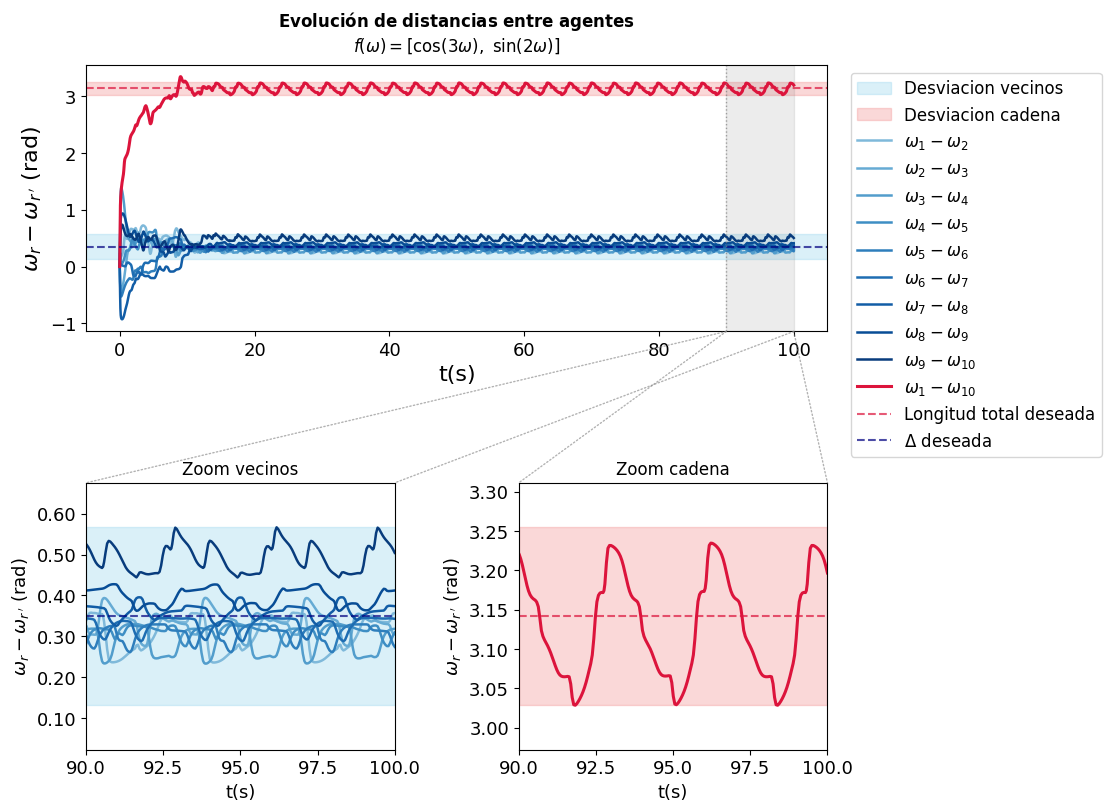

Desviacion maxima vecinos: 0.2176
Desviacion maxima vecinos normalizada: 0.0346
Desviacion maxima cadena: 0.1131
Desviacion maxima cadena normalizada: 0.0180


In [13]:
from matplotlib.patches import ConnectionPatch

# Parámetros de control de la visualización
zoom = True
zvec = 10  # Factor para la porción final de tiempo en el zoom de vecinos (azul)
zcad = 10  # Factor para la porción final de tiempo en el zoom de cadena (rojo)

Dist = []
for i in range(nrob - 1):
    Dist.append(trayectoria.y[3*i+2] - trayectoria.y[3*(i+1)+2])
Dist = np.array(Dist)

t_mitad = trayectoria.t[-1] / 2
mask_estable = trayectoria.t >= t_mitad

T = 2 * np.pi

desv_vecinos = np.max(np.abs(Dist[:, mask_estable] - abs(delta[0])))

n_dif = nrob - 1
col_dif = plt.cm.Blues(np.linspace(0.45, 0.95, n_dif))
col_tot = 'crimson'

if nrob > 2:
    dist_tot = trayectoria.y[2] - trayectoria.y[3*nrob-1]
    desv_cadena = np.max(np.abs(dist_tot[mask_estable] - abs(delta[-1])))

# 1. Creación dinámica de la figura basada en los switches 'zoom' y 'nrob'
if zoom and nrob > 2:
    mosaic = [['main', 'main'],
              ['zoom_azul', 'zoom_rojo']]
    fig, axd = plt.subplot_mosaic(mosaic, figsize=(11, 8), constrained_layout=True)
    ax = axd['main']
else:
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

# 2. Configuración de la gráfica principal
ax.set_title(r"$\mathbf{Evolución\ de\ distancias\ entre\ agentes}$" + "\n" + r"$f(\omega) = " + f_latex + r"$", pad=10)

ax.axhspan(abs(delta[0]) - desv_vecinos, abs(delta[0]) + desv_vecinos, color='skyblue', alpha=0.3, zorder=0, label='Desviacion vecinos')

if nrob > 2:
    ax.axhspan(abs(delta[-1]) - desv_cadena, abs(delta[-1]) + desv_cadena, color='lightcoral', alpha=0.3, zorder=0, label='Desviacion cadena')

for i in range(n_dif):
    ax.plot(trayectoria.t, Dist[i], color=col_dif[i], lw=1.8, label=rf'$\omega_{{{i+1}}} - \omega_{{{i+2}}}$')

if nrob > 2:
    ax.plot(trayectoria.t, dist_tot, color=col_tot, lw=2.2, label=rf'$\omega_1 - \omega_{{{nrob}}}$')
    ax.axhline(abs(delta[-1]), ls='--', color=col_tot, alpha=.7, label='Longitud total deseada')

ax.axhline(abs(delta[0]), ls='--', color='navy', alpha=.7, label=r'$\Delta$ deseada')

ax.set_xlabel('t(s)', fontsize=16)
ax.set_ylabel(r"$\omega_r - \omega_{r\,'}$ (rad)", fontsize=16)
ax.tick_params(axis='both', labelsize=13)
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.02, 1.0))

# 3. Lógica e inserción de los subplots de Zoom
if zoom:
    t_final = trayectoria.t[-1]
    t_inicio_vec = t_final - (t_final / zvec)
    t_inicio_cad = t_final - (t_final / zcad)

    if nrob > 2:
        # --- Franja gris en la principal marcando la zona ampliada ---
        x_ini_marca = min(t_inicio_vec, t_inicio_cad)
        ax.axvspan(x_ini_marca, t_final, color='gray', alpha=0.15, zorder=0)
        ax.axvline(x_ini_marca, color='gray', ls=':', lw=1, alpha=0.7)

        # Zoom panel azul
        az = axd['zoom_azul']
        az.axhspan(abs(delta[0]) - desv_vecinos, abs(delta[0]) + desv_vecinos, color='skyblue', alpha=0.3, zorder=0)
        for i in range(n_dif):
            az.plot(trayectoria.t, Dist[i], color=col_dif[i], lw=1.8)
        az.axhline(abs(delta[0]), ls='--', color='navy', alpha=.7)
        az.set_xlim(t_inicio_vec, t_final)
        az.set_ylim(abs(delta[0]) - desv_vecinos*1.5, abs(delta[0]) + desv_vecinos*1.5)
        az.set_xticks(np.linspace(t_inicio_vec, t_final, 5))
        az.set_title('Zoom vecinos', fontsize=12)
        az.set_xlabel('t(s)', fontsize=13)
        az.set_ylabel(r"$\omega_r - \omega_{r\,'}$ (rad)", fontsize=13)
        az.ticklabel_format(axis='y', style='plain')
        az.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        az.tick_params(labelsize=13)

        # Zoom panel rojo
        ro = axd['zoom_rojo']
        ro.axhspan(abs(delta[-1]) - desv_cadena, abs(delta[-1]) + desv_cadena, color='lightcoral', alpha=0.3, zorder=0)
        ro.plot(trayectoria.t, dist_tot, color=col_tot, lw=2.2)
        ro.axhline(abs(delta[-1]), ls='--', color=col_tot, alpha=.7)
        ro.set_xlim(t_inicio_cad, t_final)
        ro.set_ylim(abs(delta[-1]) - desv_cadena*1.5, abs(delta[-1]) + desv_cadena*1.5)
        ro.set_xticks(np.linspace(t_inicio_cad, t_final, 5))
        ro.set_title('Zoom cadena', fontsize=12)
        ro.set_xlabel('t(s)', fontsize=13)
        ro.set_ylabel(r"$\omega_r - \omega_{r\,'}$ (rad)", fontsize=13)
        ro.ticklabel_format(axis='y', style='plain')
        ro.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        ro.tick_params(labelsize=13)

        # --- Lineas grises que conectan la franja con cada panel de zoom ---
        for panel, x_ini in [(az, t_inicio_vec), (ro, t_inicio_cad)]:
            for x_anchor in [x_ini, t_final]:
                con = ConnectionPatch(
                    xyA=(x_anchor, ax.get_ylim()[0]), coordsA=ax.transData,
                    xyB=(x_anchor, panel.get_ylim()[1]), coordsB=panel.transData,
                    color='gray', ls=':', lw=1, alpha=0.6)
                fig.add_artist(con)

    else:
        # Inset para nrob <= 2
        az = inset_axes(ax, width="42%", height="42%", loc='lower right', borderpad=2.0)
        az.axhspan(abs(delta[0]) - desv_vecinos, abs(delta[0]) + desv_vecinos, color='skyblue', alpha=0.3, zorder=0)
        for i in range(n_dif):
            az.plot(trayectoria.t, Dist[i], color=col_dif[i], lw=1.8)
        az.axhline(abs(delta[0]), ls='--', color='navy', alpha=.7)
        az.set_xlim(t_inicio_vec, t_final)
        az.set_ylim(abs(delta[0]) - desv_vecinos*1.5, abs(delta[0]) + desv_vecinos*1.5)
        az.set_xticks(np.linspace(t_inicio_vec, t_final, 5))
        az.ticklabel_format(axis='y', style='plain')
        az.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
        az.yaxis.set_major_locator(plt.MaxNLocator(5))
        az.tick_params(labelsize=11)

        # --- Marca de la zona ampliada + lineas grises de conexion ---
        ax.indicate_inset_zoom(az, edgecolor="gray", alpha=0.6)

plt.show()

# 4. Impresión de resultados numéricos
print(f"Desviacion maxima vecinos: {desv_vecinos:.4f}")
print(f"Desviacion maxima vecinos normalizada: {desv_vecinos / T:.4f}")
if nrob > 2:
    print(f"Desviacion maxima cadena: {desv_cadena:.4f}")
    print(f"Desviacion maxima cadena normalizada: {desv_cadena / T:.4f}")

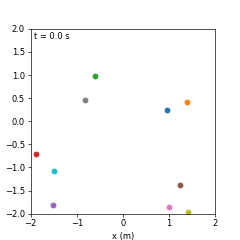

In [14]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

#Elegimos paso y tiemp  del gif
paso = 1
t_anim = 25

#Definimos lo rápido que se reproduce el gif
v_gif = 0.8
fps_base = 15

#Elegimos si queremos que se vaya borrando la trayectoria. Con False, se queda todo. L_estela da la longitud
estela = True
L_estela = 10   # nº de frames de cola visible (solo si estela=True)

if t_anim is None:
    mask_anim = slice(None)
else:
    mask_anim = trayectoria.t <= t_anim

Y = trayectoria.y[:, mask_anim][:, ::paso]
T = trayectoria.t[mask_anim][::paso]
n_frames = Y.shape[1]

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(posmin, posmax)
ax.set_ylim(posmin, posmax)
ax.set_aspect('equal')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')

estelas = [ax.plot([], [])[0] for _ in range(nrob)]
puntos  = [ax.plot([], [], marker='o')[0] for _ in range(nrob)]
texto_t = ax.text(0.02, 0.98, '', transform=ax.transAxes,
                  ha='left', va='top')

def update(frame):
    ini = max(0, frame + 1 - L_estela) if estela else 0
    for i in range(nrob):
        x = Y[i*3,   ini:frame+1]
        y = Y[i*3+1, ini:frame+1]
        estelas[i].set_data(x, y)
        puntos[i].set_data([x[-1]], [y[-1]])
    texto_t.set_text(f't = {T[frame]:.1f} s')
    return estelas + puntos + [texto_t]

ani = FuncAnimation(fig, update, frames=n_frames, blit=True)
ani.save('trayectorias.gif', writer=PillowWriter(fps=fps_base * v_gif), dpi=60)
plt.close(fig)

Image(filename='trayectorias.gif')